In [1]:
import io
import os
from google.colab import drive
drive.mount('/content/gdrive')
import sys

fs="\t"
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/gdrive


In [2]:
# Load the dataset
df = pd.read_csv('/content/gdrive/MyDrive/Colab Notebooks/kampala_final_with_kt_jose.csv', parse_dates=['datetime'])
df.set_index('datetime', inplace=True)

In [3]:
df.head() #visualise the dataset in brief

,Year,Month,Day,Hour,Minute,Temperature,Alpha,Aerosol Optical Depth,Asymmetry,Clearsky DHI,...,minute_of_day,day_of_year,sin_minute,cos_minute,sin_day,cos_day,optimal_tilt,optimal_azimuth,max_poa_irradiance,clearness_index_kt
datetime,,,,,,,,,,,,,,,,,,,,,
2017-01-01 07:00:00+03:00,2017,1,1,7,0,20.5,0.75,0.111,0.61,14,...,420,1,0.965926,-0.258819,0.017202,0.999852,0.000000,113.002263,8.000000,0.005658
2017-01-01 07:15:00+03:00,2017,1,1,7,15,21.0,0.75,0.111,0.61,32,...,435,1,0.946930,-0.321439,0.017202,0.999852,35.067611,113.104143,32.695459,0.021217
2017-01-01 07:30:00+03:00,2017,1,1,7,30,21.5,0.75,0.111,0.61,48,...,450,1,0.923880,-0.382683,0.017202,0.999852,53.403853,113.296079,83.825645,0.045969
2017-01-01 07:45:00+03:00,2017,1,1,7,45,22.0,0.78,0.103,0.61,58,...,465,1,0.896873,-0.442289,0.017202,0.999852,0.000000,113.581251,40.205142,0.028289
2017-01-01 08:00:00+03:00,2017,1,1,8,0,22.6,0.78,0.103,0.61,68,...,480,1,0.866025,-0.500000,0.017202,0.999852,26.274383,113.964572,97.528909,0.065772


In [4]:
# Split data: 2017-2020 train, 2021 test
train_df = df[df.index.year <= 2020]
test_df = df[df.index.year == 2021]

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")

Training data shape: (67378, 35)
Test data shape: (16840, 35)


In [5]:
# Feature engineering
feature_cols = [
    'GHI', 'DNI', 'DHI', 'Temperature', 'Precipitable Water', 'Relative Humidity',
    'Pressure', 'Wind Speed', 'sin_minute', 'cos_minute', 'sin_day', 'cos_day', 'clearness_index_kt'
]
target_cols = ['optimal_tilt', 'optimal_azimuth']

X_train = train_df[feature_cols].values
y_train_tilt = train_df['optimal_tilt'].values
y_train_az = train_df['optimal_azimuth'].values

X_test = test_df[feature_cols].values
y_test_tilt = test_df['optimal_tilt'].values
y_test_az = test_df['optimal_azimuth'].values

In [6]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

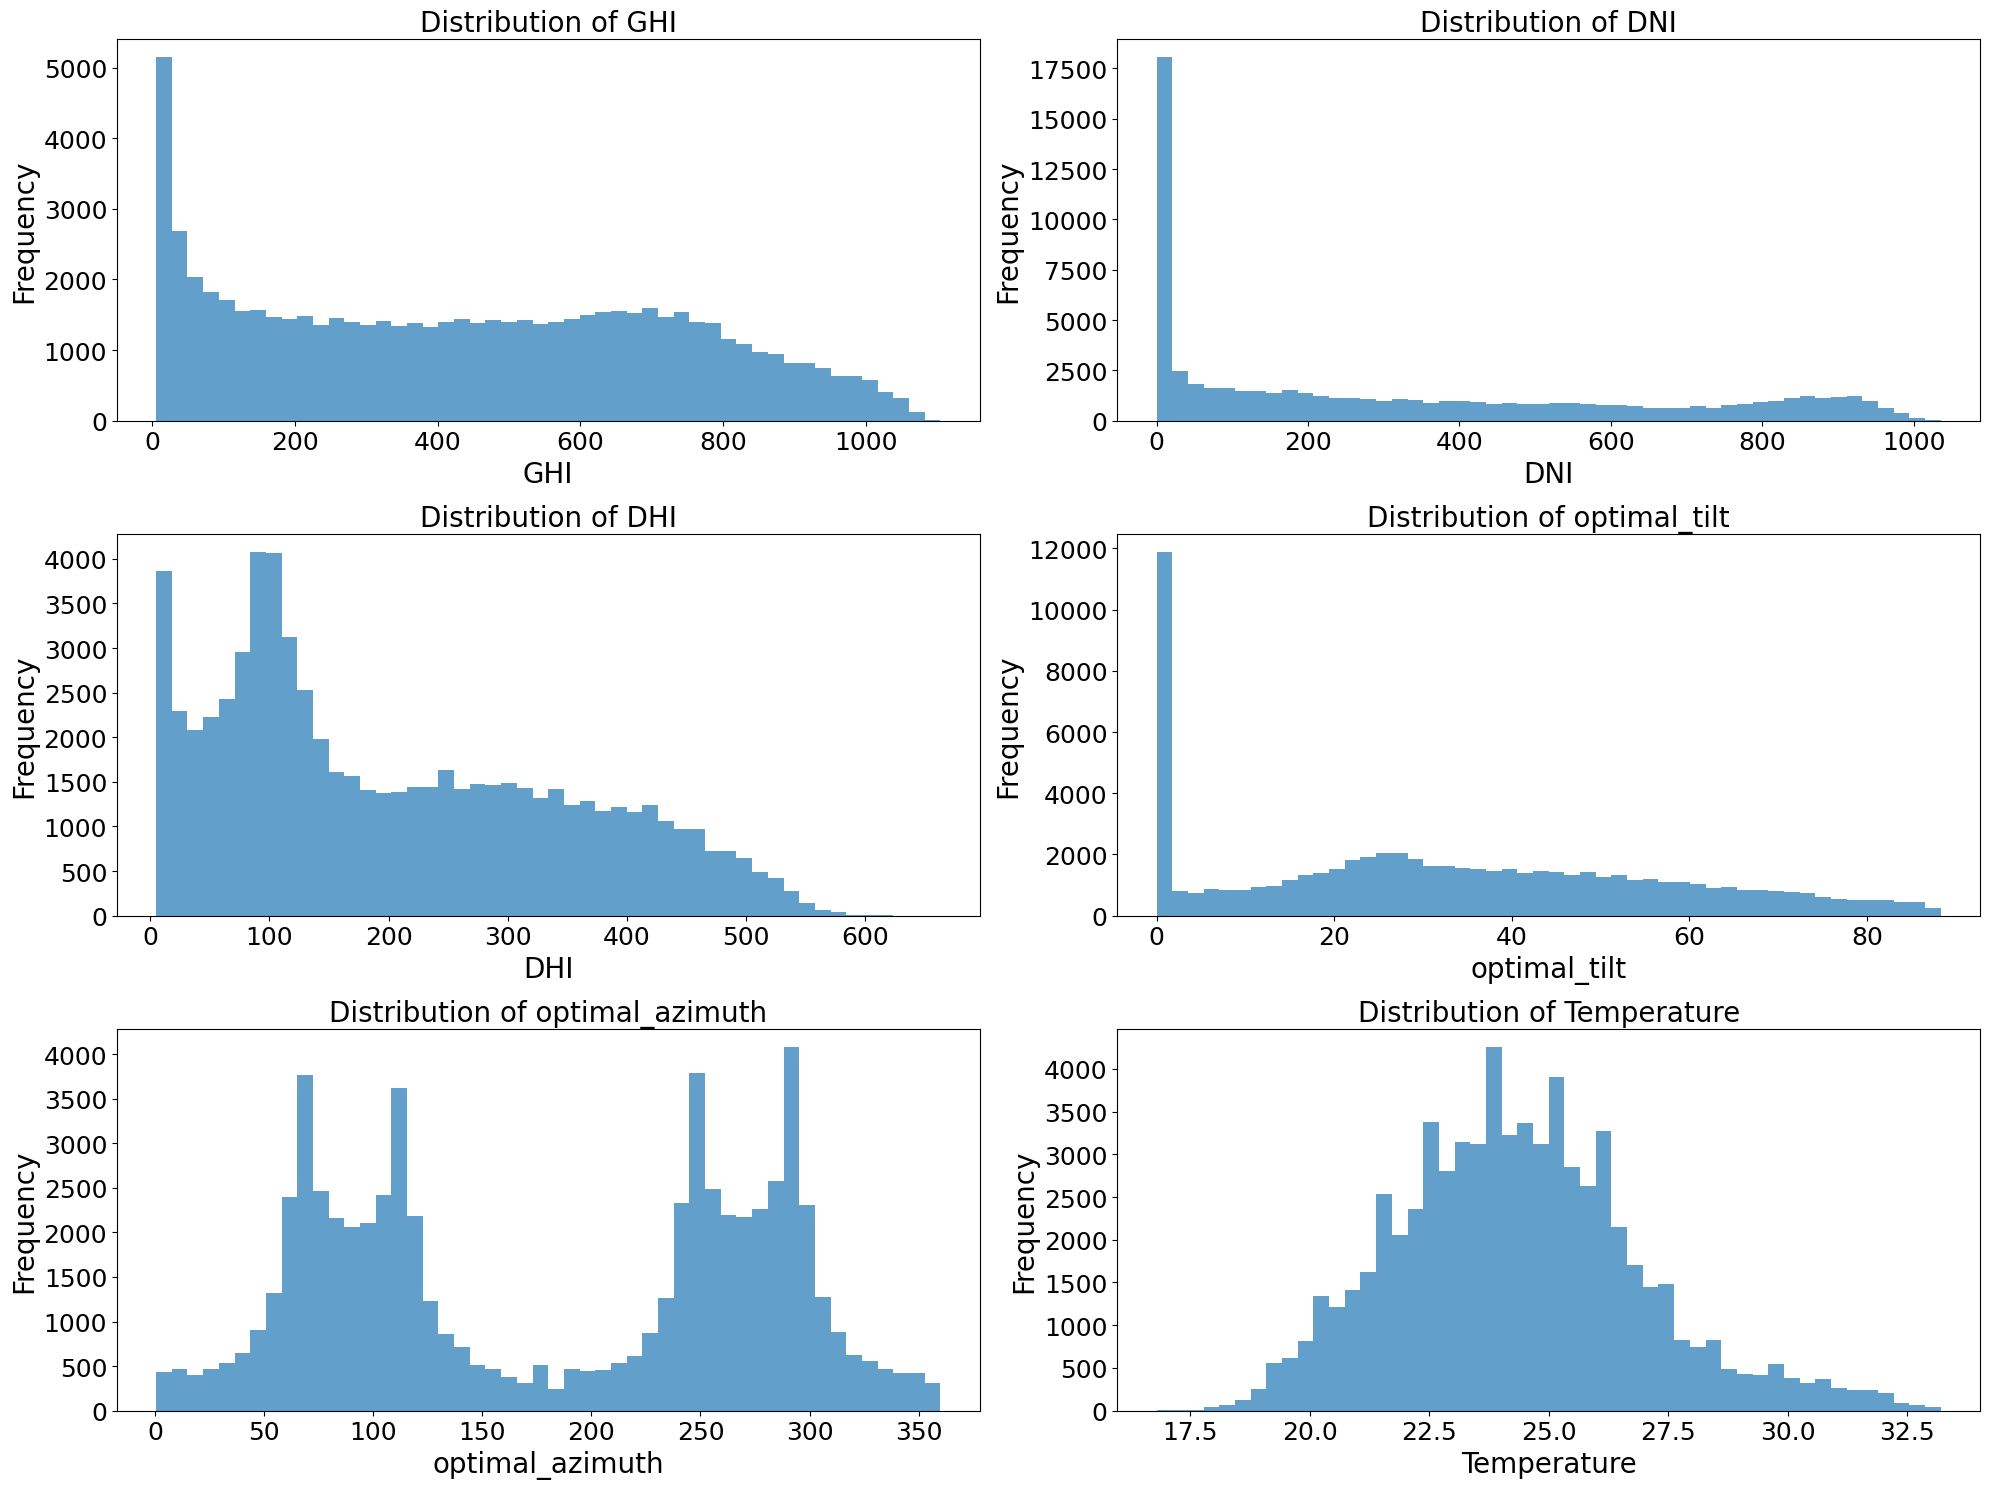

In [7]:
# --- EDA Section ---
plt.figure(figsize=(20, 15))

# 1. Distributions of key features and targets
key_features = ['GHI', 'DNI', 'DHI', 'optimal_tilt', 'optimal_azimuth', 'Temperature']
for i, col in enumerate(key_features, 1):
    plt.subplot(3, 2, i)
    plt.hist(train_df[col], bins=50, alpha=0.7)
    plt.title(f'Distribution of {col}', fontsize=20)
    plt.xlabel(col, fontsize=20)
    plt.ylabel('Frequency', fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)

plt.tight_layout()
plt.savefig('/content/gdrive/MyDrive/Colab Notebooks/eda_distributions.pdf', bbox_inches='tight')
plt.show()

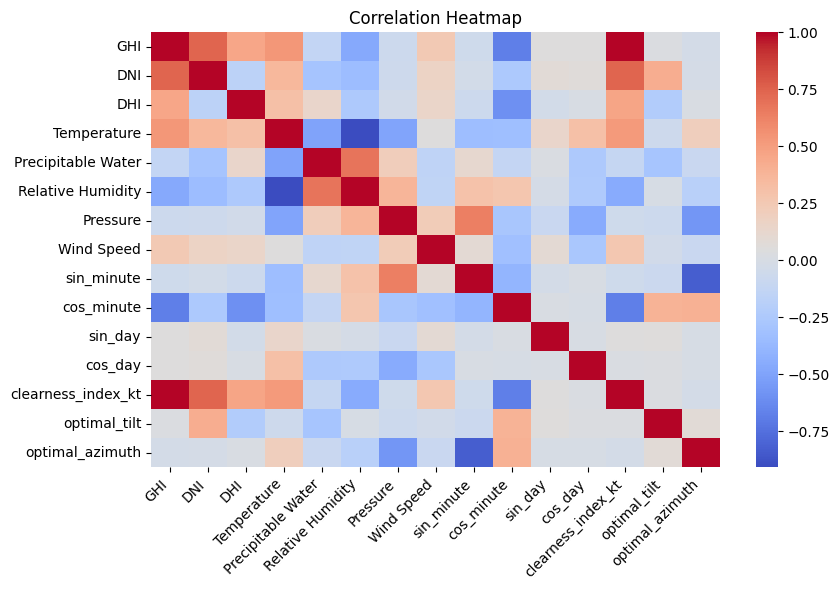

In [8]:
# 2. Correlation heatmap
plt.figure(figsize=(16, 6))   # wide figure

plt.subplot(1, 2, 1)
corr_matrix = train_df[feature_cols + target_cols].corr()

ax = sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')

# Slant x-axis labels
plt.xticks(rotation=45, ha='right')  # rotate 45° and right-align
plt.yticks(rotation=0)               # keep y-labels horizontal

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()


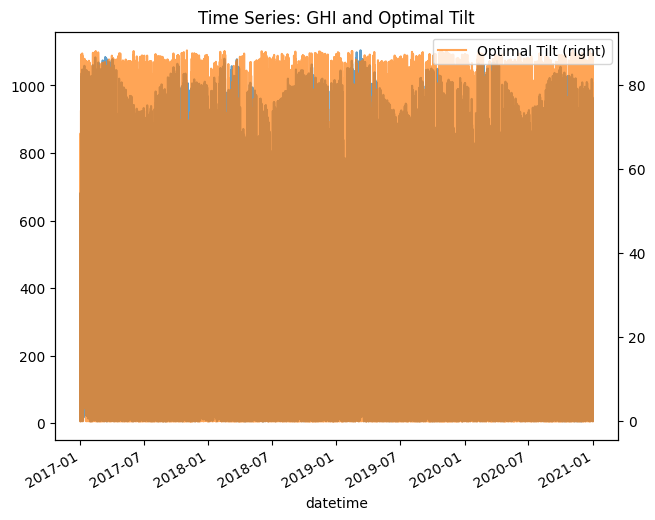

In [9]:
# 3. Time series plot of irradiance and optimal angles
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 2)
train_df['GHI'].plot(label='GHI', alpha=0.7)
train_df['optimal_tilt'].plot(secondary_y=True, label='Optimal Tilt', alpha=0.7)
plt.title('Time Series: GHI and Optimal Tilt')
plt.legend()
plt.savefig('/content/gdrive/MyDrive/Colab Notebooks/eda_timeseries.pdf', bbox_inches='tight')
plt.show()

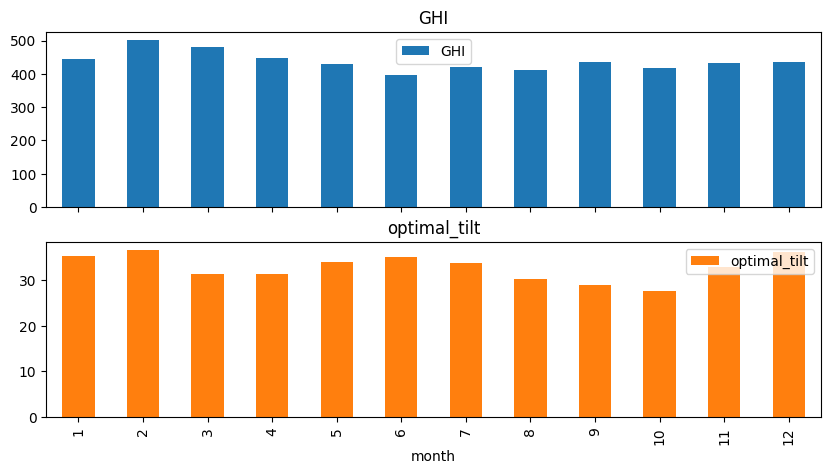

In [10]:
# 4. Seasonal variation
train_df['month'] = train_df.index.month
monthly_avg = train_df.groupby('month')[['GHI', 'optimal_tilt']].mean()
monthly_avg.plot(kind='bar', subplots=True, figsize=(10, 5))
plt.savefig('/content/gdrive/MyDrive/Colab Notebooks/eda_seasonal.pdf', bbox_inches='tight')
plt.show()

In [11]:
# --- Hyper-parameter Search ---
# Subsample for faster tuning (10% of train)
subsample_idx = np.random.choice(len(X_train), size=int(0.1 * len(X_train)), replace=False)
X_sub = X_train[subsample_idx]
y_sub_tilt = y_train_tilt[subsample_idx]
y_sub_az = y_train_az[subsample_idx]
X_sub_scaled = scaler.transform(X_sub)

In [12]:
# RF Hyperparam search
print("Hyperparam search for RF...")
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20]
}
rf_tilt_gs = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3, scoring='r2')
rf_tilt_gs.fit(X_sub, y_sub_tilt)
best_rf_tilt = rf_tilt_gs.best_estimator_

rf_az_gs = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3, scoring='r2')
rf_az_gs.fit(X_sub, y_sub_az)
best_rf_az = rf_az_gs.best_estimator_

print(f"Best RF params Tilt: {rf_tilt_gs.best_params_}")
print(f"Best RF params Az: {rf_az_gs.best_params_}")

Hyperparam search for RF...
Best RF params Tilt: {'max_depth': 20, 'n_estimators': 100}
Best RF params Az: {'max_depth': 20, 'n_estimators': 100}


In [13]:
# MLP Hyperparam search
print("Hyperparam search for MLP...")
mlp_params = {
    'hidden_layer_sizes': [(50, 25), (100, 50)],
    'alpha': [0.0001, 0.001]
}
mlp_tilt_gs = GridSearchCV(MLPRegressor(max_iter=200, random_state=42), mlp_params, cv=3, scoring='r2')
mlp_tilt_gs.fit(X_sub_scaled, y_sub_tilt)
best_mlp_tilt = mlp_tilt_gs.best_estimator_

mlp_az_gs = GridSearchCV(MLPRegressor(max_iter=200, random_state=42), mlp_params, cv=3, scoring='r2')
mlp_az_gs.fit(X_sub_scaled, y_sub_az)
best_mlp_az = mlp_az_gs.best_estimator_

print(f"Best MLP params Tilt: {mlp_tilt_gs.best_params_}")
print(f"Best MLP params Az: {mlp_az_gs.best_params_}")

Hyperparam search for MLP...
Best MLP params Tilt: {'alpha': 0.001, 'hidden_layer_sizes': (100, 50)}
Best MLP params Az: {'alpha': 0.001, 'hidden_layer_sizes': (100, 50)}


In [14]:
# LSTM: Simple manual tuning (e.g., units=25 or 50)
# For now, use 50 as before; can add more if needed

# --- Train with best params ---
# RF
rf_pred_tilt = best_rf_tilt.predict(X_test)
rf_pred_az = best_rf_az.predict(X_test)

# MLP
mlp_pred_tilt = best_mlp_tilt.predict(X_test_scaled)
mlp_pred_az = best_mlp_az.predict(X_test_scaled)

In [15]:
# LSTM (no tuning for now)
def create_sequences(X, y, lookback=6):
    Xs, ys_tilt, ys_az = [], [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i:(i + lookback)])
        ys_tilt.append(y[i + lookback])
        ys_az.append(y[i + lookback])
    return np.array(Xs), np.array(ys_tilt), np.array(ys_az)

lookback = 6
X_train_lstm, y_train_lstm_tilt, y_train_lstm_az = create_sequences(X_train_scaled, y_train_tilt, lookback)
X_test_lstm, y_test_lstm_tilt, y_test_lstm_az = create_sequences(X_test_scaled, y_test_tilt, lookback)

In [16]:
lstm_tilt = Sequential()
lstm_tilt.add(LSTM(50, return_sequences=True, input_shape=(lookback, len(feature_cols))))
lstm_tilt.add(Dropout(0.2))
lstm_tilt.add(LSTM(50, return_sequences=False))
lstm_tilt.add(Dropout(0.2))
lstm_tilt.add(Dense(25))
lstm_tilt.add(Dense(1))
lstm_tilt.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
early_stop = EarlyStopping(monitor='val_loss', patience=5)
lstm_tilt.fit(X_train_lstm, y_train_lstm_tilt, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=0)

lstm_az = Sequential()
lstm_az.add(LSTM(50, return_sequences=True, input_shape=(lookback, len(feature_cols))))
lstm_az.add(Dropout(0.2))
lstm_az.add(LSTM(50, return_sequences=False))
lstm_az.add(Dropout(0.2))
lstm_az.add(Dense(25))
lstm_az.add(Dense(1))
lstm_az.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
lstm_az.fit(X_train_lstm, y_train_lstm_az, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=0)

lstm_pred_tilt = lstm_tilt.predict(X_test_lstm).flatten()
lstm_pred_az = lstm_az.predict(X_test_lstm).flatten()

527/527 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
527/527 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [17]:
# --- Evaluation ---
def evaluate_model(y_true_tilt, y_pred_tilt, y_true_az, y_pred_az, model_name):
    mae_tilt = mean_absolute_error(y_true_tilt, y_pred_tilt)
    rmse_tilt = np.sqrt(mean_squared_error(y_true_tilt, y_pred_tilt))
    r2_tilt = r2_score(y_true_tilt, y_pred_tilt)

    mae_az = mean_absolute_error(y_true_az, y_pred_az)
    rmse_az = np.sqrt(mean_squared_error(y_true_az, y_pred_az))
    r2_az = r2_score(y_true_az, y_pred_az)

    print(f"\n{model_name} Results:")
    print(f"Tilt - MAE: {mae_tilt:.4f}, RMSE: {rmse_tilt:.4f}, R²: {r2_tilt:.4f}")
    print(f"Azimuth - MAE: {mae_az:.4f}, RMSE: {rmse_az:.4f}, R²: {r2_az:.4f}")

    return {
        'tilt_mae': mae_tilt, 'tilt_rmse': rmse_tilt, 'tilt_r2': r2_tilt,
        'az_mae': mae_az, 'az_rmse': rmse_az, 'az_r2': r2_az
    }

rf_results = evaluate_model(y_test_tilt, rf_pred_tilt, y_test_az, rf_pred_az, "Random Forest")
mlp_results = evaluate_model(y_test_tilt, mlp_pred_tilt, y_test_az, mlp_pred_az, "MLP")
lstm_results = evaluate_model(y_test_lstm_tilt, lstm_pred_tilt, y_test_lstm_az, lstm_pred_az, "LSTM")


Random Forest Results:
Tilt - MAE: 1.5409, RMSE: 3.3719, R²: 0.9803
Azimuth - MAE: 0.8582, RMSE: 5.8926, R²: 0.9963

MLP Results:
Tilt - MAE: 2.2525, RMSE: 4.4735, R²: 0.9652
Azimuth - MAE: 3.0591, RMSE: 7.3154, R²: 0.9943

LSTM Results:
Tilt - MAE: 7.4262, RMSE: 13.1862, R²: 0.6980
Azimuth - MAE: 7.5936, RMSE: 13.5634, R²: 0.6804


In [18]:
# Best model
models_results = {
    'RF': (rf_results['tilt_r2'] + rf_results['az_r2']) / 2,
    'MLP': (mlp_results['tilt_r2'] + mlp_results['az_r2']) / 2,
    'LSTM': (lstm_results['tilt_r2'] + lstm_results['az_r2']) / 2
}

best_model = max(models_results, key=models_results.get)
print(f"\nBest model based on average R²: {best_model} with score {models_results[best_model]:.4f}")


Best model based on average R²: RF with score 0.9883


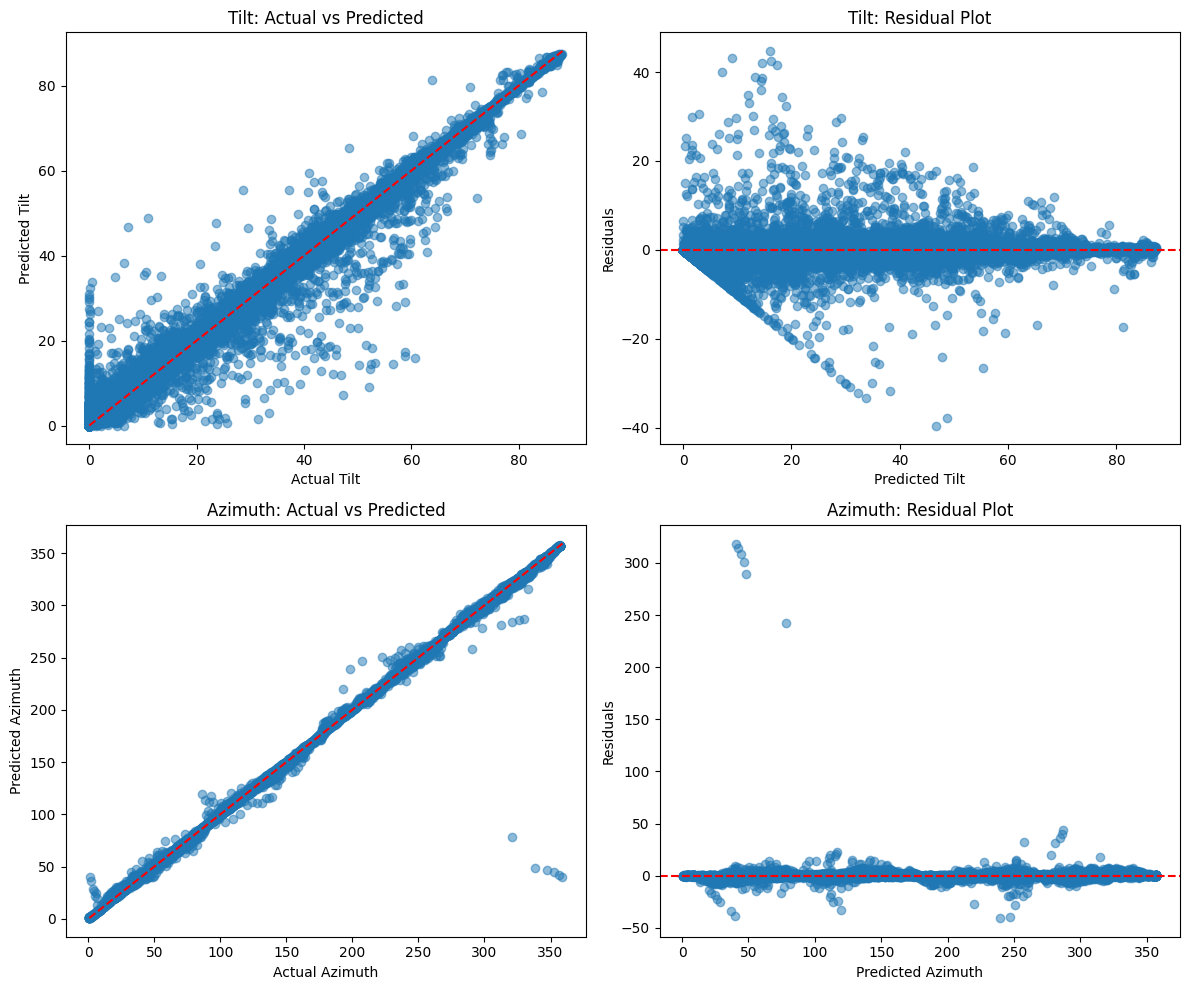

In [19]:
# --- Performance Visuals ---
# Actual vs Predicted for best model (assume RF for example; adjust if needed)
if best_model == 'RF':
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Tilt actual vs pred
    axes[0,0].scatter(y_test_tilt, rf_pred_tilt, alpha=0.5)
    axes[0,0].plot([y_test_tilt.min(), y_test_tilt.max()], [y_test_tilt.min(), y_test_tilt.max()], 'r--')
    axes[0,0].set_xlabel('Actual Tilt')
    axes[0,0].set_ylabel('Predicted Tilt')
    axes[0,0].set_title('Tilt: Actual vs Predicted')

    # Tilt residuals
    residuals_tilt = y_test_tilt - rf_pred_tilt
    axes[0,1].scatter(rf_pred_tilt, residuals_tilt, alpha=0.5)
    axes[0,1].axhline(y=0, color='r', linestyle='--')
    axes[0,1].set_xlabel('Predicted Tilt')
    axes[0,1].set_ylabel('Residuals')
    axes[0,1].set_title('Tilt: Residual Plot')

    # Azimuth actual vs pred
    axes[1,0].scatter(y_test_az, rf_pred_az, alpha=0.5)
    axes[1,0].plot([y_test_az.min(), y_test_az.max()], [y_test_az.min(), y_test_az.max()], 'r--')
    axes[1,0].set_xlabel('Actual Azimuth')
    axes[1,0].set_ylabel('Predicted Azimuth')
    axes[1,0].set_title('Azimuth: Actual vs Predicted')

    # Azimuth residuals
    residuals_az = y_test_az - rf_pred_az
    axes[1,1].scatter(rf_pred_az, residuals_az, alpha=0.5)
    axes[1,1].axhline(y=0, color='r', linestyle='--')
    axes[1,1].set_xlabel('Predicted Azimuth')
    axes[1,1].set_ylabel('Residuals')
    axes[1,1].set_title('Azimuth: Residual Plot')

    plt.tight_layout()
    #plt.savefig('performance_visuals.png')
    plt.savefig('/content/gdrive/MyDrive/Colab Notebooks/performance_visuals.pdf', bbox_inches='tight')

    plt.show()


--- Feature Importance Analysis (Random Forest) ---


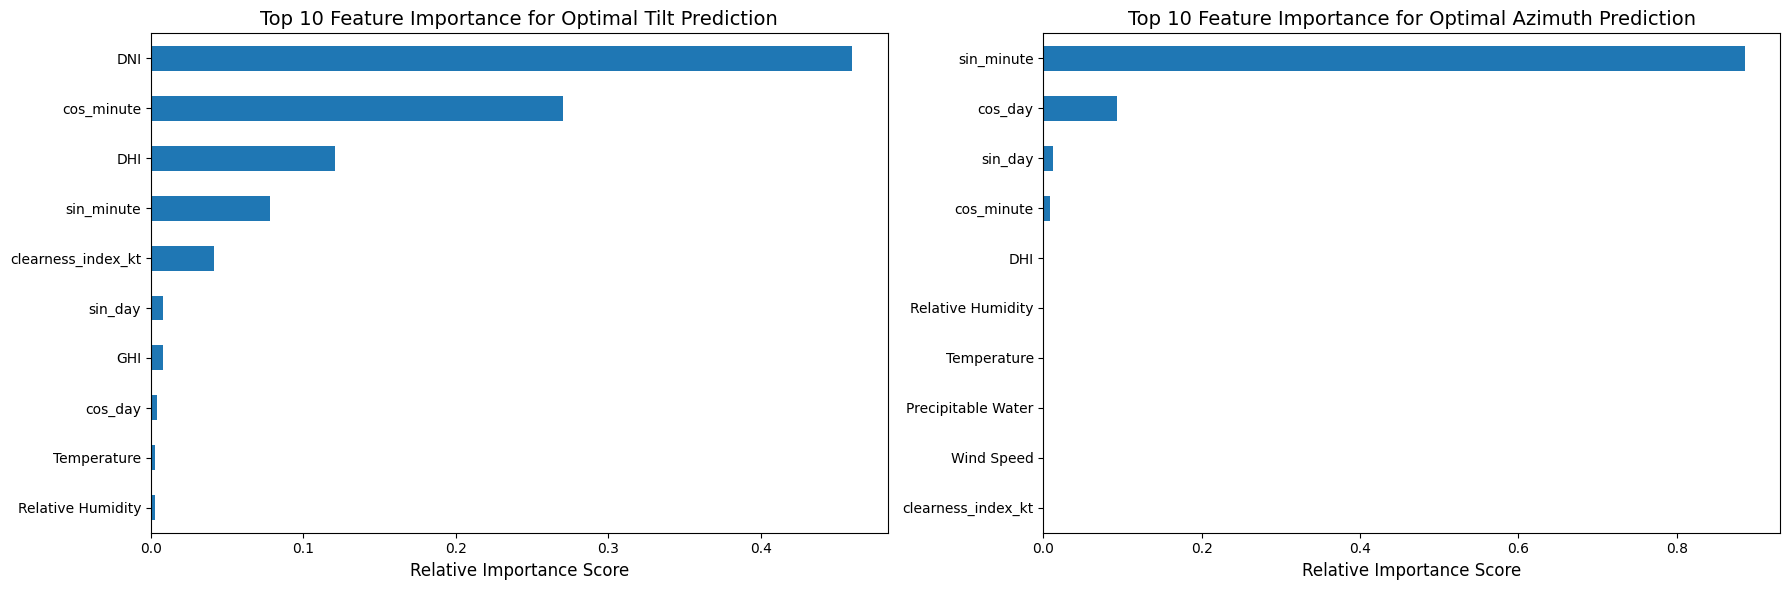

In [20]:
## --- Enhanced Analysis: Feature Importance ---
print("\n--- Feature Importance Analysis (Random Forest) ---")

# Ensure the feature_cols list is available
feature_cols = [
    'GHI', 'DNI', 'DHI', 'Temperature', 'Precipitable Water', 'Relative Humidity',
    'Pressure', 'Wind Speed', 'sin_minute', 'cos_minute', 'sin_day', 'cos_day', 'clearness_index_kt'
]

if best_model == 'RF':
    # Get importance for Tilt
    importances_tilt = best_rf_tilt.feature_importances_
    feature_importances_tilt = pd.Series(importances_tilt, index=feature_cols).sort_values(ascending=False)

    # Get importance for Azimuth
    importances_az = best_rf_az.feature_importances_
    feature_importances_az = pd.Series(importances_az, index=feature_cols).sort_values(ascending=False)

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    # Tilt Plot
    feature_importances_tilt.head(10).plot(kind='barh', ax=ax[0])
    ax[0].set_title('Top 10 Feature Importance for Optimal Tilt Prediction', fontsize=14)
    ax[0].set_xlabel('Relative Importance Score', fontsize=12)
    ax[0].invert_yaxis()

    # Azimuth Plot
    feature_importances_az.head(10).plot(kind='barh', ax=ax[1])
    ax[1].set_title('Top 10 Feature Importance for Optimal Azimuth Prediction', fontsize=14)
    ax[1].set_xlabel('Relative Importance Score', fontsize=12)
    ax[1].invert_yaxis()

    plt.tight_layout()
    #plt.savefig('feature_importance.png')
    plt.savefig('/content/gdrive/MyDrive/Colab Notebooks/feature_importance_RF.pdf', bbox_inches='tight')

    plt.show()
else:
    print("Feature importance only computed for the Random Forest model.")


--- Temporal Error Analysis ---
       Monthly MAE Tilt  Monthly MAE Azimuth
Month                                       
1              1.755906             0.384615
2              1.994127             0.789068
3              1.633937             1.387685
4              1.244059             1.068517
5              1.430731             0.730796
6              1.260312             0.318026
7              1.211700             0.306548
8              1.403430             0.771918
9              1.730946             2.683398
10             1.706125             1.019672
11             1.654454             0.583119
12             1.501968             0.318149


<Figure size 1200x600 with 0 Axes>

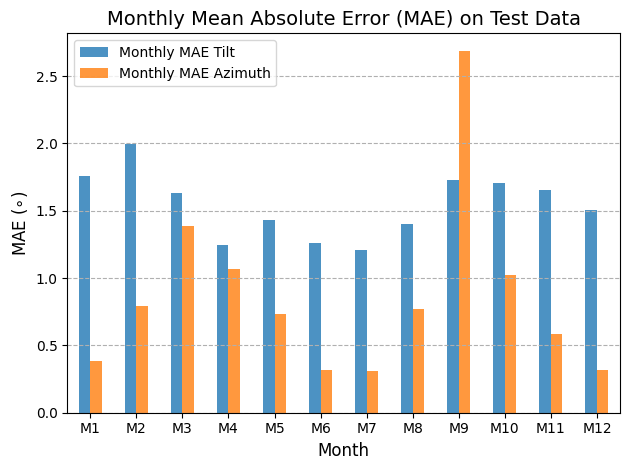

In [21]:
## --- Enhanced Analysis: Temporal Error Analysis ---
print("\n--- Temporal Error Analysis ---")

# Use the test index and residuals from the best model (using RF results for demonstration)
if best_model == 'RF':
    # Create a DataFrame for easy temporal grouping
    test_df_eval = test_df.iloc[lookback:] # Aligning index for fair comparison, use the original test_df if using RF/MLP without lookback

    # Since RF and MLP didn't use lookback, we use the original test_df index
    test_df_results = test_df.copy()
    test_df_results['RF_Residuals_Tilt'] = y_test_tilt - rf_pred_tilt
    test_df_results['RF_Residuals_Az'] = y_test_az - rf_pred_az

    test_df_results['Month'] = test_df_results.index.month

    # Calculate Mean Absolute Error (MAE) per month
    monthly_mae = test_df_results.groupby('Month')[['RF_Residuals_Tilt', 'RF_Residuals_Az']].apply(
        lambda x: x.abs().mean()
    )
    monthly_mae.columns = ['Monthly MAE Tilt', 'Monthly MAE Azimuth']
    print(monthly_mae)

    # Plotting Monthly MAE
    plt.figure(figsize=(12, 6))
    monthly_mae.plot(kind='bar', rot=0, alpha=0.8)
    plt.title('Monthly Mean Absolute Error (MAE) on Test Data', fontsize=14)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('MAE ($\circ$)', fontsize=12)
    plt.legend(fontsize=10)
    plt.xticks(ticks=range(len(monthly_mae.index)), labels=[f'M{m}' for m in monthly_mae.index])
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    #plt.savefig('monthly_mae_analysis.png')
    plt.savefig('/content/gdrive/MyDrive/Colab Notebooks/monthly_mae_analysis.pdf', bbox_inches='tight')
    plt.show()

In [22]:
# Save models (example for best RF)
import joblib
if best_model == 'RF':
    joblib.dump(best_rf_tilt, 'best_solar_tracker_tilt_rf.pkl')
    joblib.dump(best_rf_az, 'best_solar_tracker_az_rf.pkl')
    print("Best models saved.")

Best models saved.
